# Heat Stroke Risk Prediction
Predict the risk of heat stroke using factors such as temperature, humidity, age, physical activity, and water intake.

This notebook includes:
- Data preprocessing
- Visualization 
- Model training & evaluation
- Risk prediction

In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [17]:
# Load dataset
# Use a robust path strategy so the notebook works when __file__ is not defined.
try:
    base_dir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    base_dir = os.getcwd()

candidate_paths = [
    os.path.join(base_dir, 'Heat Stroke (1).csv'),
    os.path.join(os.getcwd(), 'heat_stroke_risk_predictor', 'Heat Stroke (1).csv'),
]
DATA_PATH = next((p for p in candidate_paths if os.path.exists(p)), None)
if DATA_PATH is None:
    raise FileNotFoundError('Heat Stroke (1).csv not found. Place the CSV inside heat_stroke_risk_predictor/')

df = pd.read_csv(DATA_PATH)
print('Rows, Cols:', df.shape)
print('Columns:', list(df.columns))
df.head()

Rows, Cols: (609, 27)
Columns: ['Daily Ingested Water (L)', 'Time of year (month)', 'Cardiovascular disease history', 'Dehydration', 'Heat Index (HI)', 'Diastolic BP', 'Environmental temperature (C)', 'Sickle Cell Trait (SCT)', 'Systolic BP', 'Weight (kg)', 'Patient temperature', 'Rectal temperature (deg C)', 'Relative Humidity', 'Exposure to sun', 'BMI', 'Exertional (1) vs classic (0)', 'Barometric Pressure', 'Heart / Pulse rate (b/min)', 'Age', 'Sweating', 'Skin color (flushed/normal=1, pale=0.5, cyatonic=0)', 'Strenuous exercise', 'Nationality', 'Sex', 'Hot/dry skin', 'Time of day', 'Heat stroke']


,Daily Ingested Water (L),Time of year (month),Cardiovascular disease history,Dehydration,Heat Index (HI),Diastolic BP,Environmental temperature (C),Sickle Cell Trait (SCT),Systolic BP,Weight (kg),...,Heart / Pulse rate (b/min),Age,Sweating,"Skin color (flushed/normal=1, pale=0.5, cyatonic=0)",Strenuous exercise,Nationality,Sex,Hot/dry skin,Time of day,Heat stroke
0,2.821588,7.000000,0,0,107.296910,20.0,39.0,0,60.0,48.364079,...,166.0,38.0,0,0.021014,0.5,1,1,0,10.550628,1
1,5.000000,6.841842,0,0,105.410610,90.0,37.7,0,120.0,52.413863,...,68.0,50.0,1,0.045987,0.0,1,0,0,10.613669,1
2,5.000000,4.636197,0,0,101.823065,50.0,37.7,0,100.0,46.344503,...,96.0,64.0,0,0.031299,0.0,1,0,0,14.419615,1
3,10.500000,2.589828,0,0,95.925389,78.0,37.7,0,116.0,42.132476,...,70.0,19.0,0,0.052654,0.0,1,0,0,9.467515,1
4,5.000000,9.914389,0,0,101.673016,88.0,37.7,0,130.0,41.856694,...,88.0,21.0,1,0.076099,0.0,1,0,0,12.460315,1


In [18]:
df = df.copy()

# Target column
TARGET_COL_CANDIDATES = ['Heat stroke', 'HeatStroke', 'heat stroke', 'heat_stroke']
TARGET_COL = None
for c in TARGET_COL_CANDIDATES:
    if c in df.columns:
        TARGET_COL = c
        break
if TARGET_COL is None:
    for c in df.columns:
        if c.strip().lower() in {'heat stroke', 'heatstroke', 'heat_stroke'}:
            TARGET_COL = c
            break
if TARGET_COL is None:
    raise ValueError('Could not locate target column for heat stroke risk.')

df = df.dropna(subset=[TARGET_COL])
df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors='coerce')
df = df.dropna(subset=[TARGET_COL])
df[TARGET_COL] = df[TARGET_COL].astype(int)
print('Target distribution:')
df[TARGET_COL].value_counts()

Target distribution:


Heat stroke
0    500
1    109
Name: count, dtype: int64

In [19]:
# Feature selection: temperature, humidity, age, physical activity, water intake
# (The dataset has many extra features; we keep a focused subset.)
temperature_cols = [c for c in [
    'Patient temperature',
    'Rectal temperature (deg C)',
    'Environmental temperature (C)',
    'Heat Index (HI)'
] if c in df.columns]
humidity_cols = [c for c in ['Relative Humidity'] if c in df.columns]
age_cols = [c for c in ['Age'] if c in df.columns]
activity_cols = [c for c in [
    'Exertional (1) vs classic (0)',
    'Strenuous exercise'
] if c in df.columns]
water_cols = [c for c in ['Daily Ingested Water (L)'] if c in df.columns]
# Optional additional columns that often help
other_feature_cols = [c for c in [
    'BMI',
    'Sweating',
    'Exposure to sun',
    'Heart / Pulse rate (b/min)',
    'Sickle Cell Trait (SCT)',
    'Diastolic BP',
    'Systolic BP'
] if c in df.columns]

feature_cols = []
for group in [temperature_cols, humidity_cols, age_cols, activity_cols, water_cols, other_feature_cols]:
    for c in group:
        if c != TARGET_COL and c not in feature_cols:
            feature_cols.append(c)

print('Selected feature columns (count={}):'.format(len(feature_cols)))
feature_cols

X = df[feature_cols]
y = df[TARGET_COL]

Selected feature columns (count=16):


## Visualization 

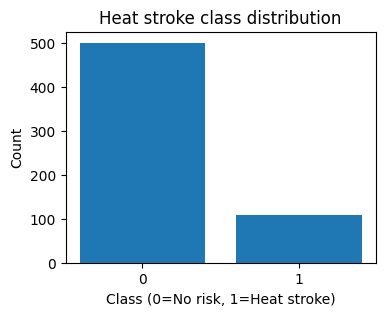

<Figure size 700x300 with 0 Axes>

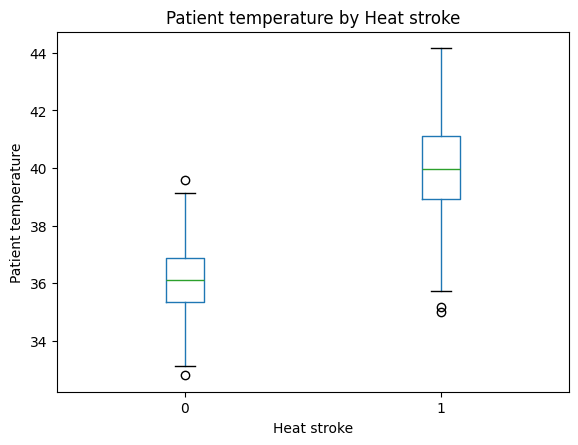

<Figure size 700x300 with 0 Axes>

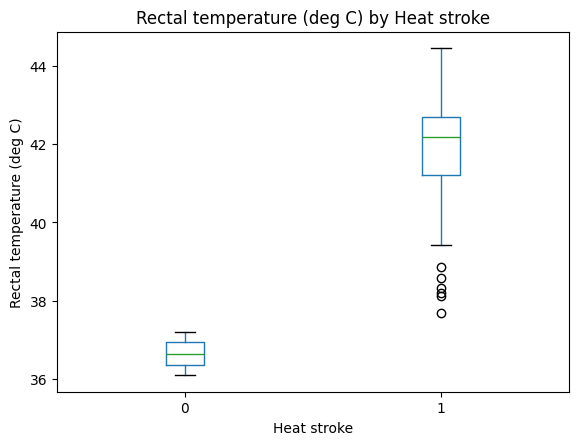

<Figure size 700x300 with 0 Axes>

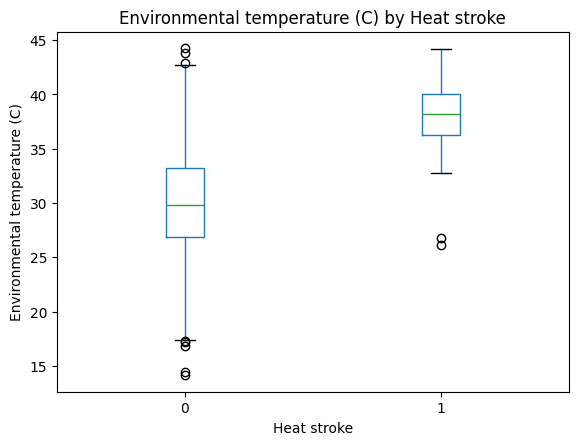

<Figure size 700x300 with 0 Axes>

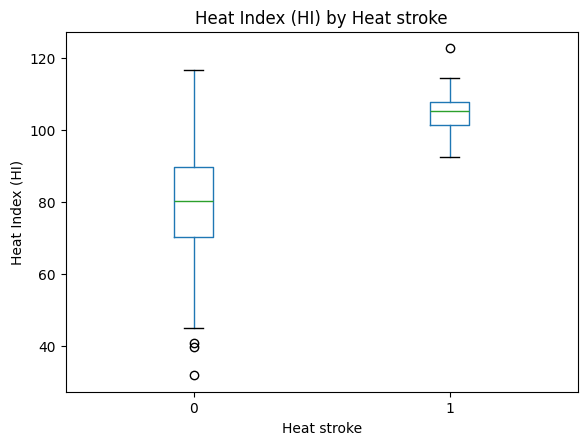

<Figure size 700x300 with 0 Axes>

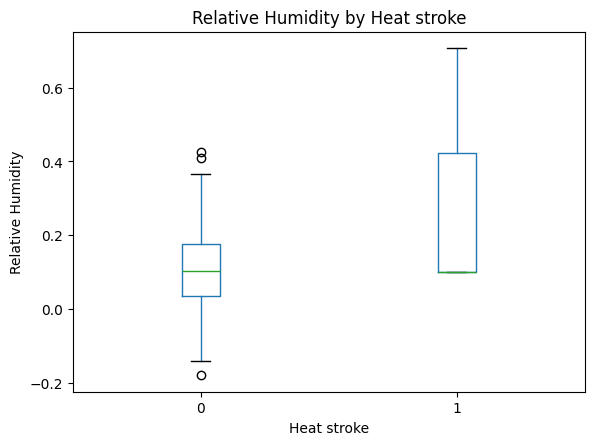

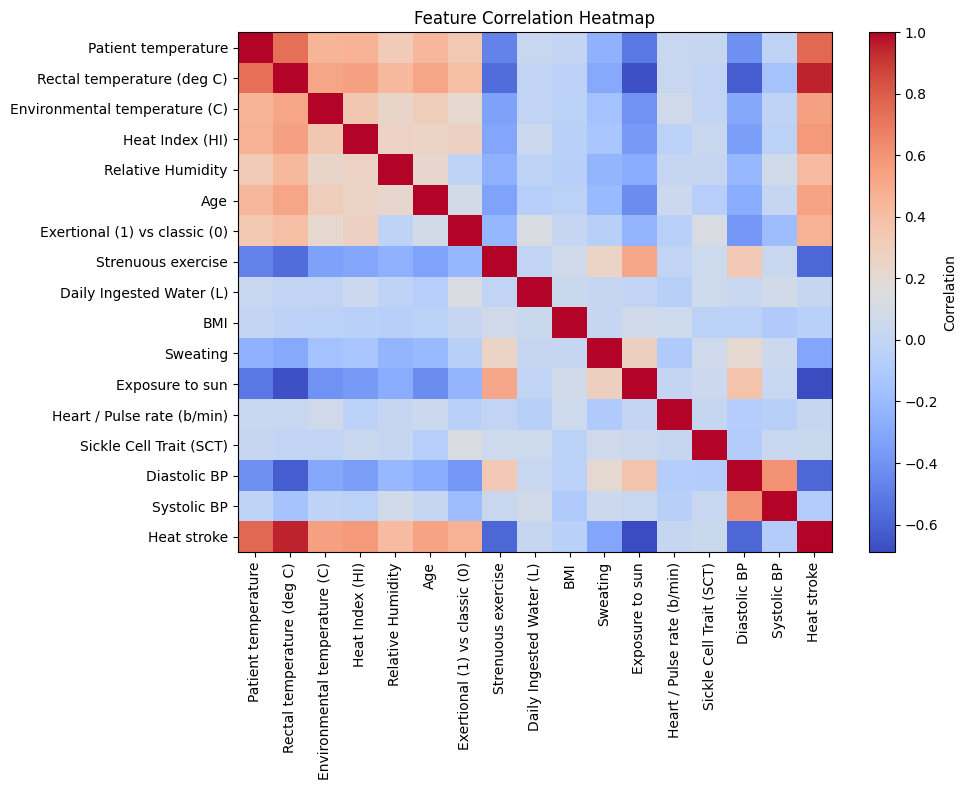

In [20]:
# Class distribution
plt.figure(figsize=(4,3))
counts = df[TARGET_COL].value_counts().sort_index()
plt.bar(counts.index.astype(str), counts.values)
plt.title('Heat stroke class distribution')
plt.xlabel('Class (0=No risk, 1=Heat stroke)')
plt.ylabel('Count')
plt.show()

# Show only top-5 key boxplots
key_plots = (temperature_cols + humidity_cols + age_cols + activity_cols + water_cols)
key_plots = [c for c in key_plots if c in df.columns]
max_boxplots = 5
key_plots = key_plots[:max_boxplots]

for col in key_plots:
    plt.figure(figsize=(7,3))
    df.boxplot(column=col, by=TARGET_COL, grid=False)
    plt.title(f'{col} by {TARGET_COL}')
    plt.suptitle('')
    plt.xlabel(TARGET_COL)
    plt.ylabel(col)
    plt.show()

# Correlation heatmap (numeric only)
num_df = df[feature_cols + [TARGET_COL]].select_dtypes(include=[np.number])
corr = num_df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
plt.imshow(corr, cmap='coolwarm', aspect='auto')
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## Train/Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Train size:', X_train.shape, 'Test size:', X_test.shape)

Train size: (487, 16) Test size: (122, 16)


## Preprocessing + Model Training

In [23]:
preprocess = ColumnTransformer(
    transformers=[
        (
            'num',
            Pipeline(steps=[
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]),
            feature_cols
        )
    ],
    remainder='drop'
)

models = {
    'LogisticRegression': LogisticRegression(max_iter=3000, class_weight='balanced'),
    'RandomForest': RandomForestClassifier(n_estimators=400, random_state=42, class_weight='balanced_subsample')
}

results = {}
for name, model in models.items():
    clf = Pipeline(steps=[('preprocess', preprocess), ('model', model)])
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = {'accuracy': acc, 'y_pred': y_pred}


    print('Model:', name)
    print('Accuracy:', acc)
    print('Confusion matrix:', confusion_matrix(y_test, y_pred))
    print('Classification report:', classification_report(y_test, y_pred))

Model: LogisticRegression
Accuracy: 1.0
Confusion matrix: [[100   0]
 [  0  22]]
Classification report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00        22

    accuracy                           1.00       122
   macro avg       1.00      1.00      1.00       122
weighted avg       1.00      1.00      1.00       122

Model: RandomForest
Accuracy: 1.0
Confusion matrix: [[100   0]
 [  0  22]]
Classification report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00        22

    accuracy                           1.00       122
   macro avg       1.00      1.00      1.00       122
weighted avg       1.00      1.00      1.00       122



## Choose Best Model & Fit on Full Data

In [24]:
best_model_name = max(results.keys(), key=lambda k: results[k]['accuracy'])
print('Best model:', best_model_name)

final_model = models[best_model_name]
final_clf = Pipeline(steps=[('preprocess', preprocess), ('model', final_model)])
final_clf.fit(X, y)

Best model: LogisticRegression


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['Patient temperature','Rectal temperature (deg C)', 'Environmental temperature (C)',...,'Sickle Cell Trait (SCT)', 'Diastolic BP','Systolic BP']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of `

## Prediction Function

In [25]:
def predict_heat_stroke_risk(
    temperature=None,
    humidity=None,
    age=None,
    physical_activity=None,
    water_intake=None,
    extra_features=None
):
    """Return predicted class and probability for heat stroke risk.

    - temperature: numeric
    - humidity: numeric (Relative Humidity)
    - age: numeric
    - physical_activity: numeric (mapped into Exertional/Strenuous columns if present)
    - water_intake: numeric (mapped into Daily Ingested Water (L) if present)
    - extra_features: dict of additional feature column values
    """

    extra_features = extra_features or {}

    row = {c: np.nan for c in feature_cols}

    # Temperature mapping (use the first matching temperature column)
    if temperature is not None:
        for c in ['Patient temperature', 'Rectal temperature (deg C)', 'Environmental temperature (C)', 'Heat Index (HI)']:
            if c in row:
                row[c] = temperature
                break

    # Humidity mapping
    if humidity is not None and 'Relative Humidity' in row:
        row['Relative Humidity'] = humidity

    # Age mapping
    if age is not None and 'Age' in row:
        row['Age'] = age

    # Physical activity mapping
    if physical_activity is not None:
        if 'Exertional (1) vs classic (0)' in row:
            row['Exertional (1) vs classic (0)'] = physical_activity
        elif 'Strenuous exercise' in row:
            row['Strenuous exercise'] = physical_activity

    # Water intake mapping
    if water_intake is not None and 'Daily Ingested Water (L)' in row:
        row['Daily Ingested Water (L)'] = water_intake

    # Extra mapping
    for k, v in extra_features.items():
        if k in row:
            row[k] = v

    X_new = pd.DataFrame([row], columns=feature_cols)

    proba = float(final_clf.predict_proba(X_new)[0][1])
    pred = int(final_clf.predict(X_new)[0])
    risk_level = 'High' if proba >= 0.5 else 'Low'
    return {
        'predicted_class': pred,
        'heat_stroke_probability': proba,
        'risk_level': risk_level
    }

## Example Predictions

In [26]:
example1 = predict_heat_stroke_risk(
    temperature=40.8,
    humidity=0.4,
    age=70,
    physical_activity=1,
    water_intake=0.5,
    extra_features={'BMI': 29.97, 'Exposure to sun': 1, 'Sweating': 1}
)
example2 = predict_heat_stroke_risk(
    temperature=37.2,
    humidity=0.25,
    age=25,
    physical_activity=0,
    water_intake=2.5,
    extra_features={'BMI': 22.0}
)
print('Example 1:', example1)
print('Example 2:', example2)

Example 1: {'predicted_class': 0, 'heat_stroke_probability': 0.1455713726536645, 'risk_level': 'Low'}
Example 2: {'predicted_class': 0, 'heat_stroke_probability': 0.0038529832201654114, 'risk_level': 'Low'}
